# Attack Graphs from MITRE ATT&CK Campaigns

## Problem

The current attacker profiling maps MITRE campaign techniques → 6 MTDSim phases → **linear parameter modifiers** (speed multipliers, success bonuses). Every enhanced attacker is structurally identical — the same 6-phase kill chain with different numbers. A SolarWinds APT and a basic phishing campaign differ only in degree, not in kind.

## Goal

Model campaigns as **structurally distinct attack graphs** (DAGs) where:
- **Nodes** = techniques/actions
- **Edges** = evidence-scored associations derived from cross-campaign co-occurrence, shared malware/tool intermediaries, and citation context
- Different campaigns produce **different graph shapes**, not just different parameter values

## Approach

MITRE ATT&CK does **not** provide pre-built attack graphs. The STIX bundle contains flat `campaign → uses → technique` relationships with no explicit ordering or dependencies. However:
- Techniques carry `kill_chain_phases` (14 tactics in canonical order), providing a natural layering
- Cross-campaign technique co-occurrence provides statistical association signals
- Campaign malware/tool intermediaries group functionally coupled techniques
- Shared citation sources indicate techniques documented together

These signals replace the naive fully-connected bipartite edges with **dependency-scored edges** — producing sparser, more meaningful graphs while being transparent about the inferential nature of the edge scoring.


In [1]:
import json
import math
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

# Load MITRE ATT&CK STIX bundle
with open('enterprise-attack.json', 'r') as f:
    stix_bundle = json.load(f)

objects = stix_bundle['objects']
print(f"Total STIX objects: {len(objects)}")

# Build lookup structures
objects_by_id = {}
campaigns = []
attack_patterns = {}       # stix_id -> object
relationships = []
tactics_objects = {}        # x-mitre-tactic stix_id -> object

type_counts = Counter()
rel_type_counts = Counter()

for obj in objects:
    obj_type = obj.get('type', '')
    type_counts[obj_type] += 1
    
    if obj.get('revoked', False) or obj.get('x_mitre_deprecated', False):
        continue
    
    objects_by_id[obj['id']] = obj
    
    if obj_type == 'campaign':
        campaigns.append(obj)
    elif obj_type == 'attack-pattern':
        attack_patterns[obj['id']] = obj
    elif obj_type == 'relationship':
        relationships.append(obj)
        rel_type_counts[obj['relationship_type']] += 1
    elif obj_type == 'x-mitre-tactic':
        tactics_objects[obj['id']] = obj

print(f"\nObject types: {dict(type_counts)}")
print(f"\nRelationship types: {dict(rel_type_counts)}")
print(f"\nCampaigns: {len(campaigns)}")
print(f"Attack patterns (non-revoked): {len(attack_patterns)}")
print(f"Relationships: {len(relationships)}")


Total STIX objects: 24771

Object types: {'x-mitre-matrix': 1, 'course-of-action': 268, 'malware': 696, 'tool': 91, 'x-mitre-tactic': 14, 'attack-pattern': 835, 'x-mitre-analytic': 1739, 'x-mitre-data-component': 109, 'x-mitre-data-source': 38, 'intrusion-set': 187, 'campaign': 52, 'x-mitre-detection-strategy': 691, 'relationship': 20048, 'identity': 1, 'marking-definition': 1}

Relationship types: {'uses': 17270, 'mitigates': 1445, 'subtechnique-of': 477, 'detects': 691, 'revoked-by': 140, 'attributed-to': 25}

Campaigns: 52
Attack patterns (non-revoked): 691
Relationships: 20048


In [2]:
# Extract canonical tactic ordering from the x-mitre-matrix object
matrix_obj = next(obj for obj in objects if obj.get('type') == 'x-mitre-matrix')
tactic_refs = matrix_obj['tactic_refs']

# Resolve tactic refs to short names
TACTIC_ORDER = []
for ref in tactic_refs:
    tactic_obj = objects_by_id.get(ref)
    if tactic_obj:
        short_name = tactic_obj['x_mitre_shortname']
        TACTIC_ORDER.append(short_name)

TACTIC_INDEX = {t: i for i, t in enumerate(TACTIC_ORDER)}

print("Canonical ATT&CK Tactic Ordering (14 tactics):")
print("=" * 50)
for i, t in enumerate(TACTIC_ORDER):
    print(f"  {i:2d}. {t}")

Canonical ATT&CK Tactic Ordering (14 tactics):
   0. reconnaissance
   1. resource-development
   2. initial-access
   3. execution
   4. persistence
   5. privilege-escalation
   6. defense-evasion
   7. credential-access
   8. discovery
   9. lateral-movement
  10. collection
  11. command-and-control
  12. exfiltration
  13. impact


## Part 1: The Current Kill Chain Model

The current attacker model in MTDSim uses a **fixed 6-phase sequential kill chain** (from `attack_operation.py`). Every attacker — regardless of MITRE campaign — follows the same graph structure. Enhanced profiles only modify the **numbers on the nodes** (durations, success rates), never the structure.

| Phase | Base Duration | Maps to ATT&CK Tactics |
|-------|--------------|------------------------|
| SCAN_HOST | 5s | Reconnaissance, Discovery |
| ENUM_HOST | 5s | Resource Development, Collection |
| SCAN_PORT | 25s | Initial Access, Execution |
| EXPLOIT_VULN | 15s | Privilege Escalation, Defense Evasion, Persistence |
| BRUTE_FORCE | 20s | Credential Access |
| SCAN_NEIGHBOR | 5s | Lateral Movement, C2, Exfiltration, Impact |

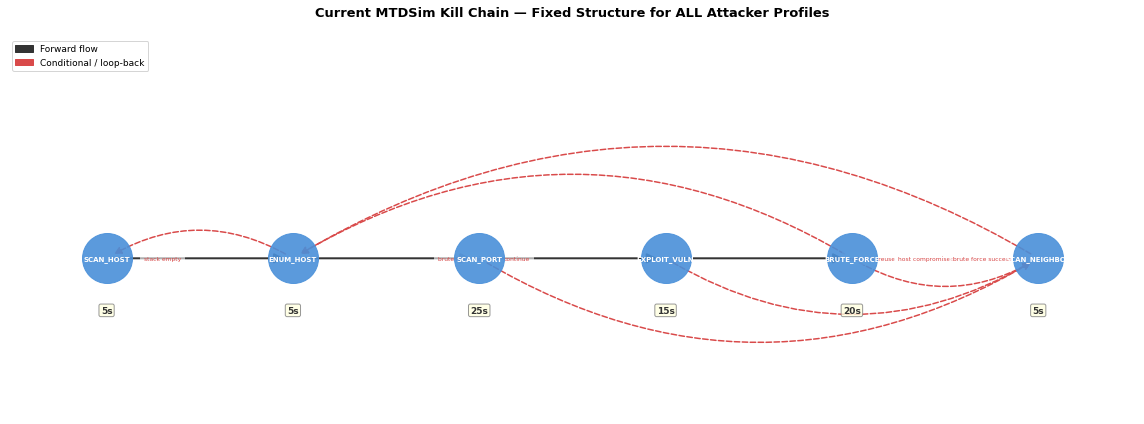


⚠ Key observation: This graph is IDENTICAL for every attacker profile.
  Enhanced profiles only change the numbers (durations, success rates),
  never the graph structure itself.


In [3]:
# Current MTDSim kill chain as a directed graph
# Shows the fixed structure from attack_operation.py

ATTACK_DURATION = {
    'SCAN_HOST': 5, 'ENUM_HOST': 5, 'SCAN_PORT': 25,
    'EXPLOIT_VULN': 15, 'BRUTE_FORCE': 20, 'SCAN_NEIGHBOR': 5,
}

G_chain = nx.DiGraph()

phases = ['SCAN_HOST', 'ENUM_HOST', 'SCAN_PORT', 'EXPLOIT_VULN', 'BRUTE_FORCE', 'SCAN_NEIGHBOR']
for p in phases:
    G_chain.add_node(p, duration=ATTACK_DURATION[p])

# Forward edges (primary kill chain flow)
forward = [
    ('SCAN_HOST', 'ENUM_HOST'),
    ('ENUM_HOST', 'SCAN_PORT'),
    ('SCAN_PORT', 'EXPLOIT_VULN'),
    ('EXPLOIT_VULN', 'BRUTE_FORCE'),
]

# Conditional / loop-back edges (from attack_operation.py)
conditional = [
    ('SCAN_PORT', 'SCAN_NEIGHBOR', 'credential reuse'),      # line 256: user_reuse → skip to scan_neighbors
    ('EXPLOIT_VULN', 'SCAN_NEIGHBOR', 'host compromised'),   # line 305: compromised → scan neighbors
    ('BRUTE_FORCE', 'SCAN_NEIGHBOR', 'brute force success'), # line 322: success → scan neighbors
    ('BRUTE_FORCE', 'ENUM_HOST', 'brute force fail'),        # line 324: fail → try next host
    ('SCAN_NEIGHBOR', 'ENUM_HOST', 'continue'),              # line 339: found neighbors → enum next
    ('ENUM_HOST', 'SCAN_HOST', 'stack empty'),               # line 93: no hosts → rescan
]

for u, v in forward:
    G_chain.add_edge(u, v, edge_type='forward')
for u, v, label in conditional:
    G_chain.add_edge(u, v, edge_type='conditional', label=label)

# Layout
pos = {
    'SCAN_HOST':    (0, 0),
    'ENUM_HOST':    (1.5, 0),
    'SCAN_PORT':    (3, 0),
    'EXPLOIT_VULN': (4.5, 0),
    'BRUTE_FORCE':  (6, 0),
    'SCAN_NEIGHBOR':(7.5, 0),
}

fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Draw forward edges
forward_edges = [(u, v) for u, v, d in G_chain.edges(data=True) if d['edge_type'] == 'forward']
cond_edges = [(u, v) for u, v, d in G_chain.edges(data=True) if d['edge_type'] == 'conditional']

nx.draw_networkx_nodes(G_chain, pos, ax=ax, node_color='#4A90D9', node_size=2500, alpha=0.9)
nx.draw_networkx_labels(G_chain, pos, ax=ax, font_size=7, font_weight='bold', font_color='white')

# Forward edges: solid arrows
nx.draw_networkx_edges(G_chain, pos, edgelist=forward_edges, ax=ax,
                       edge_color='#333', width=2, arrows=True, arrowsize=20,
                       connectionstyle='arc3,rad=0.0')

# Conditional edges: curved dashed arrows
nx.draw_networkx_edges(G_chain, pos, edgelist=cond_edges, ax=ax,
                       edge_color='#D94A4A', width=1.5, style='dashed', arrows=True, arrowsize=15,
                       connectionstyle='arc3,rad=0.3')

# Add duration annotations
for node, (x, y) in pos.items():
    dur = ATTACK_DURATION[node]
    ax.text(x, y - 0.15, f'{dur}s', ha='center', va='top', fontsize=9,
            fontweight='bold', color='#333',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

# Edge labels for conditional
edge_labels = {(u, v): d.get('label', '') for u, v, d in G_chain.edges(data=True) if d['edge_type'] == 'conditional'}
nx.draw_networkx_edge_labels(G_chain, pos, edge_labels, ax=ax, font_size=6, font_color='#D94A4A',
                             label_pos=0.3, bbox=dict(alpha=0.6, facecolor='white', edgecolor='none'))

# Legend
legend_elements = [
    mpatches.Patch(color='#333', label='Forward flow'),
    mpatches.Patch(color='#D94A4A', label='Conditional / loop-back'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

ax.set_title("Current MTDSim Kill Chain — Fixed Structure for ALL Attacker Profiles",
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlim(-0.8, 8.3)
ax.set_ylim(-0.5, 0.7)
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n⚠ Key observation: This graph is IDENTICAL for every attacker profile.")
print("  Enhanced profiles only change the numbers (durations, success rates),")
print("  never the graph structure itself.")

## Part 2: Evidence-Scored Attack Graph Construction

### The Core Limitation

ATT&CK is a **descriptive ontology** of adversary behaviour, not a causal workflow engine. It records *what* techniques were observed in a campaign, but not their sequence, prerequisites, or dependencies. The STIX data contains **no explicit sequence, AND/OR, or temporal ordering fields** on campaign-technique relationships.

This means any attack graph we build is an **evidence-scored approximation** — a technique association DAG, not a proven causal chain.

### Approach: Evidence-Scored DAG

We construct attack graphs using the canonical tactic ordering as layers, then score edges using three structural evidence signals from the STIX data:

| Signal | Type | What it captures |
|--------|------|------------------|
| **Cross-campaign co-occurrence** | Statistical (51 campaigns) | Technique pairs that appear together across multiple campaigns more than chance expects (PMI) |
| **Shared malware/tool** | Structural (within campaign) | Techniques implemented by the same campaign malware/tool — functional coupling |
| **Citation co-occurrence** | Metadata (within campaign) | Techniques documented in the same threat report — operational proximity |

### Edge Classification

Each edge between techniques in adjacent tactic layers is classified by evidence strength:

- **Strong evidence** (2+ signals): High-confidence association — multiple independent signals support this edge
- **Moderate evidence** (1 signal): Supported by a single signal
- **Fallback** (0 signals): No direct evidence, but added to preserve graph reachability (bounded, not full bipartite)

### Assumptions

1. Techniques that co-occur across multiple campaigns have a statistical association worth preserving as edges (purely data-driven, most defensible)
2. Techniques sharing a campaign malware/tool have functional coupling through shared implementation
3. Techniques cited in the same source were documented together, suggesting operational proximity
4. Tactic ordering provides reasonable directionality for edge flow

### Limitations

1. **Co-occurrence ≠ causation.** Frequently co-occurring techniques may be independently popular, not sequentially dependent. PMI mitigates chance co-occurrence but cannot prove causation.
2. **No temporal ordering.** The STIX data lacks `first_seen`/`last_seen` on campaign-technique relationships.
3. **Evidence signals indicate association, not sequence.** Graphs show which techniques are likely to appear together, not their exact within-layer order.
4. **Sparse campaigns degrade gracefully.** Campaigns with few malware/tools and single citation sources get mostly fallback edges (structurally similar to bipartite).
5. **Reporting bias.** Well-documented campaigns (e.g., SolarWinds) contribute disproportionately to co-occurrence counts.


In [4]:
# --- Data extraction helpers ---

# Build relationship index: source_ref -> list of relationships
rels_by_source = defaultdict(list)
rels_by_type = defaultdict(list)
for rel in relationships:
    rels_by_source[rel['source_ref']].append(rel)
    rels_by_type[rel['relationship_type']].append(rel)

# Sub-technique map: child_stix_id -> parent_stix_id
subtechnique_parents = {}
for rel in rels_by_type.get('subtechnique-of', []):
    subtechnique_parents[rel['source_ref']] = rel['target_ref']

def get_ext_id(obj):
    """Extract external ID (e.g., T1059, C0024) from a STIX object."""
    for ref in obj.get('external_references', []):
        if ref.get('source_name') == 'mitre-attack' and 'external_id' in ref:
            return ref['external_id']
    return None

def get_campaign_by_ext_id(ext_id):
    """Find a campaign STIX object by its external ID (e.g., 'C0024')."""
    for c in campaigns:
        if get_ext_id(c) == ext_id:
            return c
    return None

def get_campaign_techniques(campaign_stix_id):
    """
    Extract all techniques used by a campaign, with relationship metadata.
    Returns list of dicts with technique info plus citation_sources and rel_id.
    """
    techniques = []
    seen = set()
    
    for rel in rels_by_source.get(campaign_stix_id, []):
        if rel['relationship_type'] != 'uses':
            continue
        target = objects_by_id.get(rel['target_ref'])
        if not target or target['type'] != 'attack-pattern':
            continue
        if target['id'] in seen:
            continue
        seen.add(target['id'])
        
        # Extract tactics from kill_chain_phases
        tactics = []
        for phase in target.get('kill_chain_phases', []):
            if phase.get('kill_chain_name') == 'mitre-attack':
                tactics.append(phase['phase_name'])
        
        ext_id = get_ext_id(target)
        is_sub = target.get('x_mitre_is_subtechnique', False)
        parent_id = subtechnique_parents.get(target['id'])
        parent_ext = get_ext_id(objects_by_id[parent_id]) if parent_id and parent_id in objects_by_id else None
        
        # Extract citation sources from the relationship
        citation_sources = set()
        for ref in rel.get('external_references', []):
            sn = ref.get('source_name', '')
            if sn:
                citation_sources.add(sn)
        
        techniques.append({
            'stix_id': target['id'],
            'ext_id': ext_id,
            'name': target['name'],
            'tactics': tactics,
            'is_subtechnique': is_sub,
            'parent_ext_id': parent_ext,
            'citation_sources': citation_sources,
            'rel_id': rel['id'],
        })
    
    return techniques


def build_cooccurrence_index():
    """
    Build cross-campaign co-occurrence index for all technique pairs.
    
    For each pair of techniques (A, B) that co-occur in >= 2 campaigns,
    computes count and PMI (Pointwise Mutual Information).
    
    Returns: dict mapping (ext_id_A, ext_id_B) -> {'count': int, 'pmi': float}
             where A < B lexicographically (canonical ordering).
    """
    campaign_tech_sets = []
    for c in campaigns:
        techs = set()
        for rel in rels_by_source.get(c['id'], []):
            if rel['relationship_type'] != 'uses':
                continue
            target = objects_by_id.get(rel['target_ref'])
            if target and target['type'] == 'attack-pattern':
                eid = get_ext_id(target)
                if eid:
                    techs.add(eid)
        if len(techs) >= 2:
            campaign_tech_sets.append(techs)
    
    N = len(campaign_tech_sets)
    
    tech_freq = Counter()
    for techs in campaign_tech_sets:
        for t in techs:
            tech_freq[t] += 1
    
    pair_count = Counter()
    for techs in campaign_tech_sets:
        for a, b in combinations(sorted(techs), 2):
            pair_count[(a, b)] += 1
    
    index = {}
    for (a, b), count in pair_count.items():
        if count < 2:
            continue
        p_ab = count / N
        p_a = tech_freq[a] / N
        p_b = tech_freq[b] / N
        pmi = math.log2(p_ab / (p_a * p_b)) if (p_a > 0 and p_b > 0) else 0.0
        index[(a, b)] = {'count': count, 'pmi': pmi}
    
    return index


def get_campaign_software_groups(campaign_stix_id, technique_ext_ids):
    """
    Find malware/tools used by the campaign and group campaign techniques by shared software.
    Returns: dict mapping software_name -> set of technique ext_ids (groups with 2+ techniques only)
    """
    campaign_software = {}
    for rel in rels_by_source.get(campaign_stix_id, []):
        if rel['relationship_type'] != 'uses':
            continue
        target = objects_by_id.get(rel['target_ref'])
        if target and target['type'] in ('malware', 'tool'):
            campaign_software[target['id']] = target.get('name', target['id'])
    
    tech_set = set(technique_ext_ids)
    groups = {}
    for sw_id, sw_name in campaign_software.items():
        sw_techs = set()
        for rel in rels_by_source.get(sw_id, []):
            if rel['relationship_type'] != 'uses':
                continue
            target = objects_by_id.get(rel['target_ref'])
            if target and target['type'] == 'attack-pattern':
                eid = get_ext_id(target)
                if eid and eid in tech_set:
                    sw_techs.add(eid)
        if len(sw_techs) >= 2:
            groups[sw_name] = sw_techs
    
    return groups


def get_citation_clusters(techniques):
    """
    Group techniques by shared citation source.
    Filters out singletons (1 technique) and universal sources (all techniques share it).
    Returns: dict mapping source_name -> set of technique ext_ids
    """
    all_ext_ids = {t['ext_id'] for t in techniques}
    n_total = len(all_ext_ids)
    
    source_to_techs = defaultdict(set)
    for tech in techniques:
        for src in tech.get('citation_sources', set()):
            source_to_techs[src].add(tech['ext_id'])
    
    clusters = {}
    for src, tech_set in source_to_techs.items():
        if 2 <= len(tech_set) < n_total:
            clusters[src] = tech_set
    
    return clusters


# Test: extract SolarWinds (C0024) techniques with enriched metadata
c0024 = get_campaign_by_ext_id('C0024')
c0024_techs = get_campaign_techniques(c0024['id'])
print(f"SolarWinds Compromise (C0024): {len(c0024_techs)} techniques")
print(f"  Sub-techniques: {sum(1 for t in c0024_techs if t['is_subtechnique'])}")
print(f"  Tactics covered: {sorted(set(t for tech in c0024_techs for t in tech['tactics']))}")
print(f"  Techniques with citations: {sum(1 for t in c0024_techs if t['citation_sources'])}")

# Build co-occurrence index (computed once, used for all campaigns)
COOCCURRENCE_INDEX = build_cooccurrence_index()
print(f"\nCo-occurrence index: {len(COOCCURRENCE_INDEX)} technique pairs (count >= 2 across campaigns)")


SolarWinds Compromise (C0024): 71 techniques
  Sub-techniques: 49
  Tactics covered: ['collection', 'command-and-control', 'credential-access', 'defense-evasion', 'discovery', 'execution', 'exfiltration', 'initial-access', 'lateral-movement', 'persistence', 'privilege-escalation', 'reconnaissance', 'resource-development']
  Techniques with citations: 71

Co-occurrence index: 2465 technique pairs (count >= 2 across campaigns)


In [5]:
# --- Evidence signal exploration (SolarWinds C0024 as case study) ---

# 1. Data availability summary
print("=" * 70)
print("  STIX Data Availability for Dependency Inference")
print("=" * 70)

# Check campaign->uses->attack-pattern relationships for dependency-relevant fields
sample_rels = [r for r in rels_by_source.get(c0024['id'], [])
               if r['relationship_type'] == 'uses'
               and objects_by_id.get(r['target_ref'], {}).get('type') == 'attack-pattern']

fields_present = {
    'description': sum(1 for r in sample_rels if r.get('description')),
    'external_references': sum(1 for r in sample_rels if r.get('external_references')),
    'created': sum(1 for r in sample_rels if r.get('created')),
    'first_seen': sum(1 for r in sample_rels if r.get('first_seen')),
    'last_seen': sum(1 for r in sample_rels if r.get('last_seen')),
    'kill_chain_phases': sum(1 for r in sample_rels if r.get('kill_chain_phases')),
}
n_rels = len(sample_rels)
print(f"\nSolarWinds campaign->uses->attack-pattern relationships: {n_rels}")
print(f"Fields present on these relationships:")
for field, count in fields_present.items():
    status = '✓' if count > 0 else '✗'
    print(f"  {status} {field}: {count}/{n_rels}")

print(f"\n⚠ No explicit sequence, AND/OR, or temporal ordering fields found.")
print(f"  Edge scores represent statistical association and shared tooling,")
print(f"  not causal dependency.")

# 2. Co-occurrence index statistics
print(f"\n{'=' * 70}")
print(f"  Cross-Campaign Co-occurrence Index")
print(f"{'=' * 70}")
print(f"  Total technique pairs with count >= 2: {len(COOCCURRENCE_INDEX)}")
counts = [v['count'] for v in COOCCURRENCE_INDEX.values()]
pmis = [v['pmi'] for v in COOCCURRENCE_INDEX.values()]
print(f"  Co-occurrence counts: min={min(counts)}, max={max(counts)}, median={sorted(counts)[len(counts)//2]}")
print(f"  PMI range: [{min(pmis):.2f}, {max(pmis):.2f}]")
print(f"  Pairs with PMI > 0 (co-occur more than chance): {sum(1 for p in pmis if p > 0)}")

# 3. SolarWinds evidence signals
print(f"\n{'=' * 70}")
print(f"  Evidence Signals for SolarWinds (C0024)")
print(f"{'=' * 70}")

# Malware/tool groups
c0024_ext_ids = [t['ext_id'] for t in c0024_techs]
sw_groups = get_campaign_software_groups(c0024['id'], c0024_ext_ids)
print(f"\nMalware/tool groups ({len(sw_groups)} with 2+ techniques):")
for sw_name, techs in sorted(sw_groups.items(), key=lambda x: -len(x[1])):
    print(f"  {sw_name}: {len(techs)} techniques — {', '.join(sorted(techs)[:5])}{'...' if len(techs) > 5 else ''}")

# Citation clusters
cite_clusters = get_citation_clusters(c0024_techs)
print(f"\nCitation clusters ({len(cite_clusters)} discriminative sources):")
for src, techs in sorted(cite_clusters.items(), key=lambda x: -len(x[1])):
    print(f"  {src[:50]}: {len(techs)} techniques")

# Co-occurrence coverage for adjacent layers
tech_layers = {}
for t in c0024_techs:
    if t['tactics']:
        idx = min(TACTIC_INDEX.get(tac, 999) for tac in t['tactics'])
        if idx != 999:
            tech_layers[t['ext_id']] = idx

layers = defaultdict(list)
for eid, layer in tech_layers.items():
    layers[layer].append(eid)
populated = sorted(layers.keys())

total_adj_pairs = 0
cooccurrence_supported = 0
for i in range(len(populated) - 1):
    for a in layers[populated[i]]:
        for b in layers[populated[i+1]]:
            total_adj_pairs += 1
            key = tuple(sorted([a, b]))
            entry = COOCCURRENCE_INDEX.get(key)
            if entry and entry['pmi'] > 0:
                cooccurrence_supported += 1

print(f"\nAdjacent-layer edge coverage:")
print(f"  Total adjacent-layer pairs (old bipartite edges): {total_adj_pairs}")
print(f"  Pairs with co-occurrence support (PMI > 0): {cooccurrence_supported} ({cooccurrence_supported/total_adj_pairs*100:.1f}%)")
print(f"  Potential edge reduction: {(1 - cooccurrence_supported/total_adj_pairs)*100:.1f}% vs bipartite")


  STIX Data Availability for Dependency Inference

SolarWinds campaign->uses->attack-pattern relationships: 71
Fields present on these relationships:
  ✓ description: 71/71
  ✓ external_references: 71/71
  ✓ created: 71/71
  ✗ first_seen: 0/71
  ✗ last_seen: 0/71
  ✗ kill_chain_phases: 0/71

⚠ No explicit sequence, AND/OR, or temporal ordering fields found.
  Edge scores represent statistical association and shared tooling,
  not causal dependency.

  Cross-Campaign Co-occurrence Index
  Total technique pairs with count >= 2: 2465
  Co-occurrence counts: min=2, max=17, median=2
  PMI range: [-1.48, 4.67]
  Pairs with PMI > 0 (co-occur more than chance): 2342

  Evidence Signals for SolarWinds (C0024)

Malware/tool groups (11 with 2+ techniques):
  Cobalt Strike: 23 techniques — T1005, T1018, T1021.001, T1021.002, T1021.006...
  SUNBURST: 14 techniques — T1005, T1036.005, T1047, T1057, T1059.005...
  Sibot: 10 techniques — T1036.005, T1047, T1053.005, T1059.005, T1070...
  GoldMax: 7 te

In [6]:
# --- Attack graph construction (evidence-scored two-pass edge builder) ---

def _score_edge(tech_a, tech_b, cooccurrence_index, software_groups, citation_clusters):
    """
    Score a candidate edge between two techniques using three evidence signals.
    Returns (score: int, reasons: list[str]).
    """
    score = 0
    reasons = []
    
    # Signal 1: Cross-campaign co-occurrence (PMI > 0)
    key = tuple(sorted([tech_a, tech_b]))
    entry = cooccurrence_index.get(key)
    if entry and entry['pmi'] > 0:
        score += 1
        reasons.append(f"cooccurrence:pmi={entry['pmi']:.2f},count={entry['count']}")
    
    # Signal 2: Shared malware/tool
    for sw_name, sw_techs in software_groups.items():
        if tech_a in sw_techs and tech_b in sw_techs:
            score += 1
            reasons.append(f"shared_software:{sw_name}")
            break  # count once even if shared by multiple tools
    
    # Signal 3: Citation co-occurrence
    for src_name, src_techs in citation_clusters.items():
        if tech_a in src_techs and tech_b in src_techs:
            score += 1
            reasons.append(f"shared_citation:{src_name[:40]}")
            break  # count once
    
    return score, reasons


def build_campaign_attack_graph(techniques, tactic_order=TACTIC_ORDER, tactic_index=TACTIC_INDEX,
                                cooccurrence_index=None, software_groups=None, citation_clusters=None):
    """
    Build a DAG from a campaign's techniques using tactic ordering as layers
    and evidence-scored edges instead of fully-connected bipartite.
    
    Edge classes:
      - evidence_strong: 2+ independent signals support this edge
      - evidence_moderate: exactly 1 signal
      - fallback_bounded: no direct evidence, added for reachability
    
    Returns: (nx.DiGraph, dict of positions for layout)
    """
    if cooccurrence_index is None:
        cooccurrence_index = {}
    if software_groups is None:
        software_groups = {}
    if citation_clusters is None:
        citation_clusters = {}
    
    G = nx.DiGraph()
    
    # Group techniques by their earliest tactic layer
    layers = defaultdict(list)
    for tech in techniques:
        if not tech['tactics']:
            continue
        earliest_idx = min(tactic_index.get(t, 999) for t in tech['tactics'])
        if earliest_idx == 999:
            continue
        layers[earliest_idx].append(tech)
    
    if not layers:
        return G, {}
    
    populated_layers = sorted(layers.keys())
    
    # Add START and END nodes
    G.add_node('START', node_type='virtual', label='START')
    G.add_node('END', node_type='virtual', label='END')
    
    # Add technique nodes per layer
    for layer_idx in populated_layers:
        tactic_name = tactic_order[layer_idx]
        for tech in layers[layer_idx]:
            G.add_node(tech['ext_id'],
                       name=tech['name'],
                       tactics=tech['tactics'],
                       tactic_layer=layer_idx,
                       tactic_name=tactic_name,
                       is_subtechnique=tech['is_subtechnique'],
                       parent_ext_id=tech.get('parent_ext_id'),
                       node_type='technique')
    
    # --- Two-pass edge builder ---
    
    # Track bipartite count for edge_reduction metric
    bipartite_edge_count = 0
    
    for i in range(len(populated_layers)):
        curr_layer = populated_layers[i]
        curr_techs = [t['ext_id'] for t in layers[curr_layer]]
        
        # START -> first layer (always added)
        if i == 0:
            for t in curr_techs:
                G.add_edge('START', t, edge_type='flow', edge_class='start_end', edge_reason=[])
        
        # Last layer -> END (always added)
        if i == len(populated_layers) - 1:
            for t in curr_techs:
                G.add_edge(t, 'END', edge_type='flow', edge_class='start_end', edge_reason=[])
        
        # Cross-layer edges: evidence-scored
        if i < len(populated_layers) - 1:
            next_layer = populated_layers[i + 1]
            next_techs = [t['ext_id'] for t in layers[next_layer]]
            bipartite_edge_count += len(curr_techs) * len(next_techs)
            
            # Pass 1: evidence-based edges
            has_outgoing = set()  # curr techs with evidence edges out
            has_incoming = set()  # next techs with evidence edges in
            
            for t1 in curr_techs:
                for t2 in next_techs:
                    score, reasons = _score_edge(t1, t2, cooccurrence_index,
                                                software_groups, citation_clusters)
                    if score >= 2:
                        G.add_edge(t1, t2, edge_type='flow', edge_class='evidence_strong',
                                   edge_reason=reasons)
                        has_outgoing.add(t1)
                        has_incoming.add(t2)
                    elif score == 1:
                        G.add_edge(t1, t2, edge_type='flow', edge_class='evidence_moderate',
                                   edge_reason=reasons)
                        has_outgoing.add(t1)
                        has_incoming.add(t2)
            
            # Pass 2: fallback edges for reachability
            # Orphan sources: curr techs with no outgoing evidence edge
            orphan_sources = [t for t in curr_techs if t not in has_outgoing]
            # Orphan sinks: next techs with no incoming evidence edge
            orphan_sinks = [t for t in next_techs if t not in has_incoming]
            
            # Connect orphan sources to hub nodes (or all if no hubs)
            hub_targets = list(has_incoming) if has_incoming else next_techs
            for t1 in orphan_sources:
                for t2 in hub_targets:
                    if not G.has_edge(t1, t2):
                        G.add_edge(t1, t2, edge_type='flow', edge_class='fallback_bounded',
                                   edge_reason=['fallback:orphan_source'])
            
            # Connect orphan sinks from hub nodes (or all if no hubs)
            hub_sources = list(has_outgoing) if has_outgoing else curr_techs
            for t2 in orphan_sinks:
                for t1 in hub_sources:
                    if not G.has_edge(t1, t2):
                        G.add_edge(t1, t2, edge_type='flow', edge_class='fallback_bounded',
                                   edge_reason=['fallback:orphan_sink'])
    
    # Store bipartite count for metrics
    G.graph['bipartite_edge_count'] = bipartite_edge_count
    
    # Add sub-technique refinement edges
    tech_ids_in_graph = set(G.nodes())
    for tech in techniques:
        if tech['is_subtechnique'] and tech['parent_ext_id']:
            if tech['ext_id'] in tech_ids_in_graph and tech['parent_ext_id'] in tech_ids_in_graph:
                G.add_edge(tech['parent_ext_id'], tech['ext_id'], edge_type='subtechnique')
    
    # Compute positions for layered layout
    positions = {}
    positions['START'] = (-1, 0)
    positions['END'] = (len(populated_layers), 0)
    
    for li, layer_idx in enumerate(populated_layers):
        techs_in_layer = [t['ext_id'] for t in layers[layer_idx]]
        n = len(techs_in_layer)
        for j, tid in enumerate(techs_in_layer):
            y = (j - (n - 1) / 2) * 0.8
            positions[tid] = (li, y)
    
    return G, positions


def compute_graph_metrics(G):
    """Compute structural metrics for an attack graph, including evidence quality."""
    tech_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'technique']
    flow_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'flow']
    sub_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'subtechnique']
    
    # Classify flow edges by evidence class
    strong_edges = [(u, v) for u, v, d in G.edges(data=True)
                    if d.get('edge_class') == 'evidence_strong']
    moderate_edges = [(u, v) for u, v, d in G.edges(data=True)
                      if d.get('edge_class') == 'evidence_moderate']
    fallback_edges = [(u, v) for u, v, d in G.edges(data=True)
                      if d.get('edge_class') == 'fallback_bounded']
    # Exclude start_end edges from evidence counts
    cross_layer_flow = [e for e in flow_edges
                        if G.edges[e[0], e[1]].get('edge_class') != 'start_end']
    
    num_evidence = len(strong_edges) + len(moderate_edges)
    num_fallback = len(fallback_edges)
    total_cross = len(cross_layer_flow)
    
    # Width profile
    layer_counts = Counter()
    for n in tech_nodes:
        layer_counts[G.nodes[n]['tactic_layer']] += 1
    populated_layers = sorted(layer_counts.keys())
    width_profile = [(TACTIC_ORDER[l], layer_counts[l]) for l in populated_layers]
    
    # Longest path (flow edges only)
    flow_G = nx.DiGraph()
    flow_G.add_edges_from(flow_edges)
    try:
        longest = nx.dag_longest_path_length(flow_G)
    except nx.NetworkXError:
        longest = 0
    
    # Edge reduction vs bipartite
    bipartite_count = G.graph.get('bipartite_edge_count', total_cross)
    edge_reduction = 1 - (total_cross / bipartite_count) if bipartite_count > 0 else 0.0
    
    return {
        'num_techniques': len(tech_nodes),
        'num_flow_edges': len(flow_edges),
        'num_sub_edges': len(sub_edges),
        'tactic_coverage': len(populated_layers),
        'max_width': max(layer_counts.values()) if layer_counts else 0,
        'width_profile': width_profile,
        'longest_path': longest,
        'density': nx.density(G),
        # Evidence quality metrics
        'num_evidence_strong': len(strong_edges),
        'num_evidence_moderate': len(moderate_edges),
        'num_evidence_edges': num_evidence,
        'num_fallback_edges': num_fallback,
        'evidence_ratio': num_evidence / total_cross if total_cross > 0 else 0.0,
        'edge_reduction': edge_reduction,
        'bipartite_edge_count': bipartite_count,
    }


# Quick test with evidence scoring
c0024_sw_groups = get_campaign_software_groups(c0024['id'], [t['ext_id'] for t in c0024_techs])
c0024_cite_clusters = get_citation_clusters(c0024_techs)

G_test, pos_test = build_campaign_attack_graph(
    c0024_techs,
    cooccurrence_index=COOCCURRENCE_INDEX,
    software_groups=c0024_sw_groups,
    citation_clusters=c0024_cite_clusters,
)
metrics_test = compute_graph_metrics(G_test)
print(f"SolarWinds graph (evidence-scored):")
print(f"  {metrics_test['num_techniques']} techniques, {metrics_test['num_flow_edges']} flow edges")
print(f"  Evidence: {metrics_test['num_evidence_strong']} strong + {metrics_test['num_evidence_moderate']} moderate = {metrics_test['num_evidence_edges']} evidence edges")
print(f"  Fallback: {metrics_test['num_fallback_edges']} edges")
print(f"  Evidence ratio: {metrics_test['evidence_ratio']:.1%}")
print(f"  Edge reduction vs bipartite: {metrics_test['edge_reduction']:.1%} ({metrics_test['bipartite_edge_count']} -> {metrics_test['num_evidence_edges'] + metrics_test['num_fallback_edges']} cross-layer edges)")
print(f"  Tactic coverage: {metrics_test['tactic_coverage']}/14")
print(f"\nWidth profile:")
for tactic, count in metrics_test['width_profile']:
    bar = '█' * count
    print(f"  {tactic:25s} {bar} ({count})")


SolarWinds graph (evidence-scored):
  71 techniques, 254 flow edges
  Evidence: 52 strong + 125 moderate = 177 evidence edges
  Fallback: 75 edges
  Evidence ratio: 70.2%
  Edge reduction vs bipartite: 36.2% (395 -> 252 cross-layer edges)
  Tactic coverage: 13/14

Width profile:
  reconnaissance            █ (1)
  resource-development      ███ (3)
  initial-access            ████████ (8)
  execution                 █████ (5)
  persistence               █████ (5)
  privilege-escalation      █ (1)
  defense-evasion           ███████████████ (15)
  credential-access         ████████ (8)
  discovery                 ██████████ (10)
  lateral-movement          ███ (3)
  collection                ██████ (6)
  command-and-control       █████ (5)
  exfiltration              █ (1)


In [7]:
# --- Visualization helper (edge-class styling) ---

# Color map: one color per tactic
TACTIC_COLORS = plt.cm.tab20(np.linspace(0, 1, 14))

# Edge class visual styles
EDGE_STYLES = {
    'evidence_strong':  {'color': '#2C7BB6', 'width': 2.0, 'alpha': 0.8, 'style': 'solid'},
    'evidence_moderate': {'color': '#888888', 'width': 1.0, 'alpha': 0.7, 'style': 'solid'},
    'fallback_bounded':  {'color': '#CCCCCC', 'width': 0.5, 'alpha': 0.4, 'style': 'dotted'},
    'start_end':         {'color': '#999999', 'width': 1.0, 'alpha': 0.5, 'style': 'solid'},
}


def draw_attack_graph(G, positions, title, figsize=None, show_fallback=True):
    """Draw a campaign attack graph with edge-class styling and legend."""
    tech_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'technique']
    virtual_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'virtual']
    
    if not tech_nodes:
        print("No technique nodes to draw.")
        return
    
    max_width = max(
        sum(1 for n in tech_nodes if G.nodes[n]['tactic_layer'] == layer)
        for layer in set(G.nodes[n]['tactic_layer'] for n in tech_nodes)
    )
    n_layers = len(set(G.nodes[n]['tactic_layer'] for n in tech_nodes))
    if figsize is None:
        figsize = (max(14, n_layers * 2.2), max(6, max_width * 0.9))
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Node colors by tactic layer
    node_colors = []
    node_sizes = []
    for n in tech_nodes:
        layer = G.nodes[n]['tactic_layer']
        node_colors.append(TACTIC_COLORS[layer])
        node_sizes.append(200 if G.nodes[n].get('is_subtechnique') else 350)
    
    # Classify edges
    sub_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'subtechnique']
    
    # Draw edges by class (back to front: fallback, moderate, strong)
    draw_order = ['fallback_bounded', 'start_end', 'evidence_moderate', 'evidence_strong']
    for edge_class in draw_order:
        if edge_class == 'fallback_bounded' and not show_fallback:
            continue
        style_cfg = EDGE_STYLES[edge_class]
        edges = [(u, v) for u, v, d in G.edges(data=True)
                 if d.get('edge_class') == edge_class]
        if edges:
            nx.draw_networkx_edges(G, positions, edgelist=edges, ax=ax,
                                  edge_color=style_cfg['color'],
                                  width=style_cfg['width'],
                                  style=style_cfg['style'],
                                  arrows=True, arrowsize=8,
                                  alpha=style_cfg['alpha'])
    
    # Sub-technique edges (dashed orange)
    if sub_edges:
        nx.draw_networkx_edges(G, positions, edgelist=sub_edges, ax=ax,
                               edge_color='#E67E22', width=1.5, style='dashed',
                               arrows=True, arrowsize=10, alpha=0.8)
    
    # Draw technique nodes
    nx.draw_networkx_nodes(G, positions, nodelist=tech_nodes, ax=ax,
                           node_color=node_colors, node_size=node_sizes,
                           edgecolors='#333', linewidths=0.5, alpha=0.9)
    
    # Draw virtual nodes
    nx.draw_networkx_nodes(G, positions, nodelist=virtual_nodes, ax=ax,
                           node_color='#333', node_size=400, node_shape='D', alpha=0.8)
    
    # Labels
    tech_labels = {n: n for n in tech_nodes}
    virtual_labels = {n: n for n in virtual_nodes}
    nx.draw_networkx_labels(G, positions, labels=tech_labels, ax=ax,
                           font_size=5, font_weight='bold')
    nx.draw_networkx_labels(G, positions, labels=virtual_labels, ax=ax,
                           font_size=8, font_weight='bold', font_color='white')
    
    # Tactic column headers
    layer_x_positions = {}
    for n in tech_nodes:
        layer = G.nodes[n]['tactic_layer']
        x = positions[n][0]
        layer_x_positions[layer] = x
    
    y_top = max(positions[n][1] for n in G.nodes()) + 1.2
    for layer, x in layer_x_positions.items():
        tactic_label = TACTIC_ORDER[layer].replace('-', '\n')
        ax.text(x, y_top, tactic_label, ha='center', va='bottom', fontsize=7,
                fontweight='bold', color=TACTIC_COLORS[layer],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=TACTIC_COLORS[layer], alpha=0.8))
    
    # Legend for edge classes
    legend_elements = [
        mlines.Line2D([], [], color='#2C7BB6', linewidth=2.0, label='Strong evidence (2+ signals)'),
        mlines.Line2D([], [], color='#888888', linewidth=1.0, label='Moderate evidence (1 signal)'),
        mlines.Line2D([], [], color='#CCCCCC', linewidth=1.0, linestyle='dotted', label='Fallback (reachability)'),
        mlines.Line2D([], [], color='#E67E22', linewidth=1.5, linestyle='dashed', label='Sub-technique'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              framealpha=0.9, edgecolor='#ccc')
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=30)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def print_metrics(metrics, campaign_name):
    """Print formatted metrics including evidence quality."""
    print(f"\n{'=' * 65}")
    print(f"  {campaign_name} — Attack Graph Metrics")
    print(f"{'=' * 65}")
    print(f"  Techniques:         {metrics['num_techniques']}")
    print(f"  Tactic coverage:    {metrics['tactic_coverage']}/14")
    print(f"  Max layer width:    {metrics['max_width']}")
    print(f"  Longest path:       {metrics['longest_path']}")
    print(f"  Graph density:      {metrics['density']:.4f}")
    print(f"")
    print(f"  --- Edge Quality ---")
    print(f"  Flow edges (total): {metrics['num_flow_edges']}")
    print(f"  Sub-tech edges:     {metrics['num_sub_edges']}")
    print(f"  Evidence strong:    {metrics['num_evidence_strong']}")
    print(f"  Evidence moderate:  {metrics['num_evidence_moderate']}")
    print(f"  Fallback:           {metrics['num_fallback_edges']}")
    print(f"  Evidence ratio:     {metrics['evidence_ratio']:.1%}")
    print(f"  Edge reduction:     {metrics['edge_reduction']:.1%} vs bipartite ({metrics['bipartite_edge_count']} bipartite edges)")
    print(f"")
    print(f"  Width profile:")
    for tactic, count in metrics['width_profile']:
        bar = '█' * count
        print(f"    {tactic:25s} {bar} ({count})")

print("Visualization helpers defined.")


Visualization helpers defined.


## Part 3: Example Campaign Attack Graphs

Three structurally diverse campaigns to compare:

1. **SolarWinds Compromise (C0024)** — 71 techniques, sophisticated supply-chain APT with broad tactic coverage
2. **Night Dragon (C0002)** — Classic cyber espionage campaign, moderate breadth
3. **3CX Supply Chain Compromise (C0057)** — Supply chain attack, different shape

Under the current model, these differ only in scalar parameters. As attack graphs, their **shapes** should be visibly distinct.

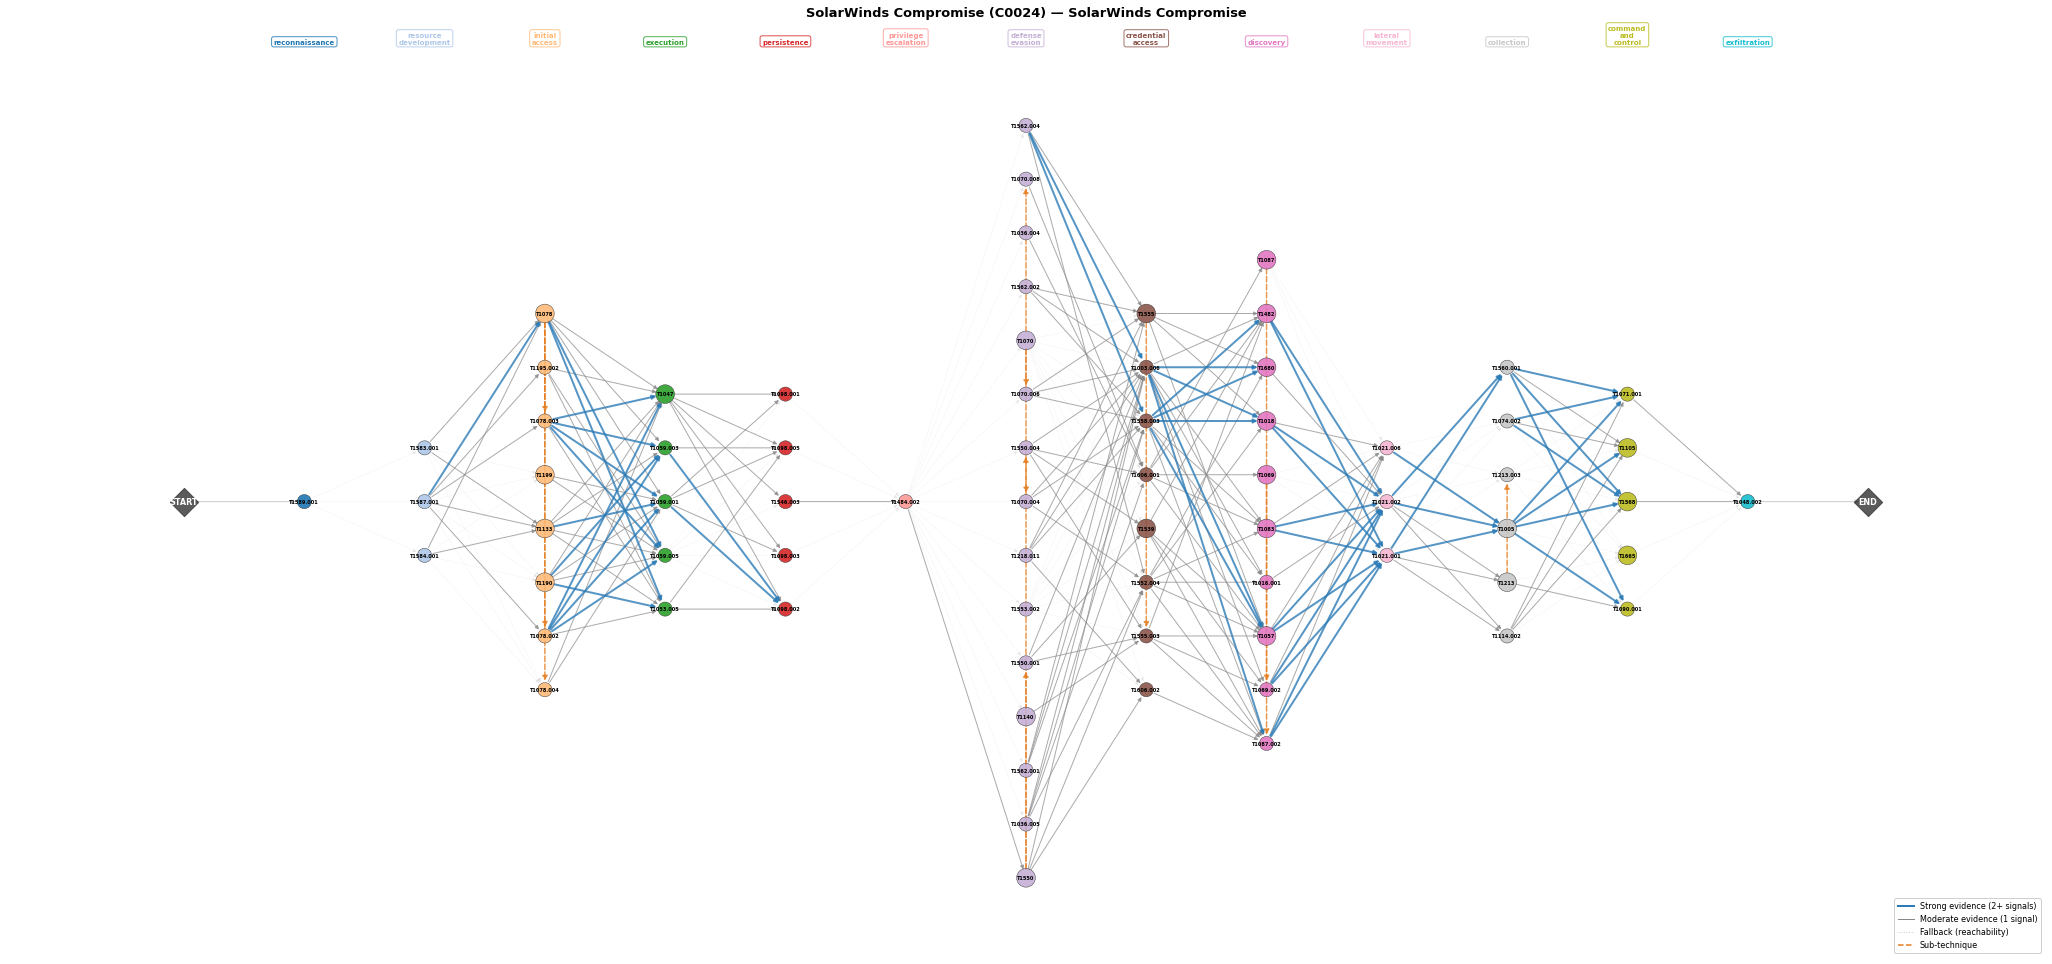


  SolarWinds Compromise — Attack Graph Metrics
  Techniques:         71
  Tactic coverage:    13/14
  Max layer width:    15
  Longest path:       14
  Graph density:      0.0506

  --- Edge Quality ---
  Flow edges (total): 254
  Sub-tech edges:     12
  Evidence strong:    52
  Evidence moderate:  125
  Fallback:           75
  Evidence ratio:     70.2%
  Edge reduction:     36.2% vs bipartite (395 bipartite edges)

  Width profile:
    reconnaissance            █ (1)
    resource-development      ███ (3)
    initial-access            ████████ (8)
    execution                 █████ (5)
    persistence               █████ (5)
    privilege-escalation      █ (1)
    defense-evasion           ███████████████ (15)
    credential-access         ████████ (8)
    discovery                 ██████████ (10)
    lateral-movement          ███ (3)
    collection                ██████ (6)
    command-and-control       █████ (5)
    exfiltration              █ (1)


In [8]:
# --- Campaign 1: SolarWinds Compromise (C0024) ---

c0024 = get_campaign_by_ext_id('C0024')
c0024_techs = get_campaign_techniques(c0024['id'])
c0024_sw_groups = get_campaign_software_groups(c0024['id'], [t['ext_id'] for t in c0024_techs])
c0024_cite_clusters = get_citation_clusters(c0024_techs)

G_solar, pos_solar = build_campaign_attack_graph(
    c0024_techs,
    cooccurrence_index=COOCCURRENCE_INDEX,
    software_groups=c0024_sw_groups,
    citation_clusters=c0024_cite_clusters,
)
m_solar = compute_graph_metrics(G_solar)

draw_attack_graph(G_solar, pos_solar,
                  f"SolarWinds Compromise (C0024) — {c0024['name']}")
print_metrics(m_solar, "SolarWinds Compromise")


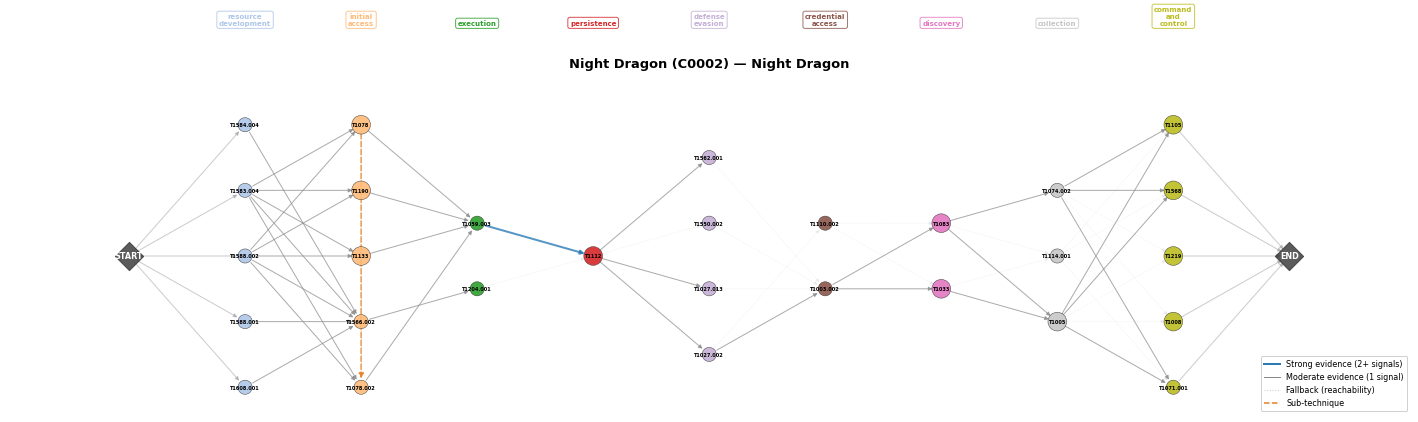


  Night Dragon — Attack Graph Metrics
  Techniques:         29
  Tactic coverage:    9/14
  Max layer width:    5
  Longest path:       10
  Graph density:      0.0667

  --- Edge Quality ---
  Flow edges (total): 61
  Sub-tech edges:     1
  Evidence strong:    1
  Evidence moderate:  33
  Fallback:           17
  Evidence ratio:     66.7%
  Edge reduction:     31.1% vs bipartite (74 bipartite edges)

  Width profile:
    resource-development      █████ (5)
    initial-access            █████ (5)
    execution                 ██ (2)
    persistence               █ (1)
    defense-evasion           ████ (4)
    credential-access         ██ (2)
    discovery                 ██ (2)
    collection                ███ (3)
    command-and-control       █████ (5)


In [9]:
# --- Campaign 2: Night Dragon (C0002) ---

c0002 = get_campaign_by_ext_id('C0002')
c0002_techs = get_campaign_techniques(c0002['id'])
c0002_sw_groups = get_campaign_software_groups(c0002['id'], [t['ext_id'] for t in c0002_techs])
c0002_cite_clusters = get_citation_clusters(c0002_techs)

G_night, pos_night = build_campaign_attack_graph(
    c0002_techs,
    cooccurrence_index=COOCCURRENCE_INDEX,
    software_groups=c0002_sw_groups,
    citation_clusters=c0002_cite_clusters,
)
m_night = compute_graph_metrics(G_night)

draw_attack_graph(G_night, pos_night,
                  f"Night Dragon (C0002) — {c0002['name']}")
print_metrics(m_night, "Night Dragon")


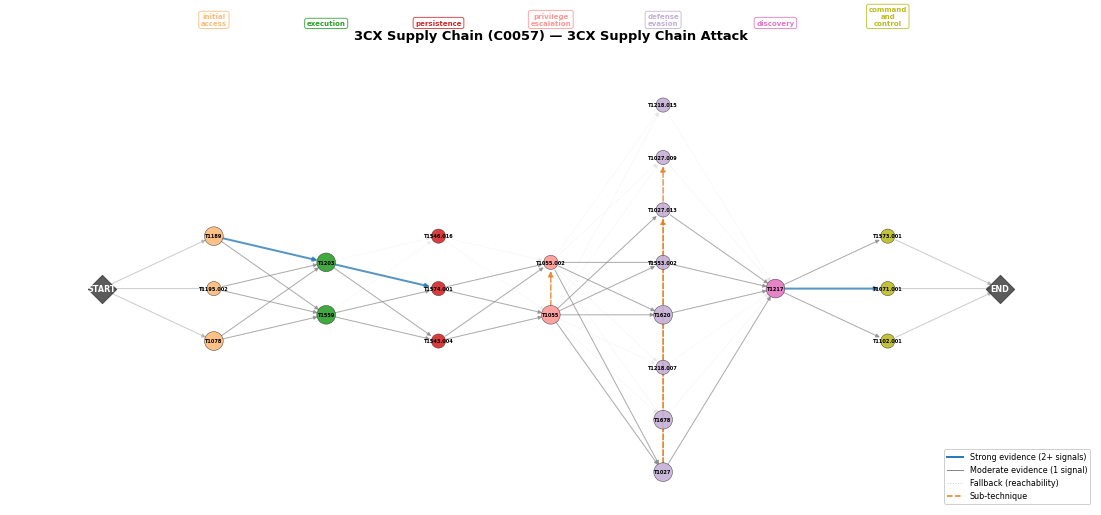


  3CX Supply Chain — Attack Graph Metrics
  Techniques:         22
  Tactic coverage:    7/14
  Max layer width:    8
  Longest path:       8
  Graph density:      0.0960

  --- Edge Quality ---
  Flow edges (total): 50
  Sub-tech edges:     3
  Evidence strong:    3
  Evidence moderate:  25
  Fallback:           16
  Evidence ratio:     63.6%
  Edge reduction:     2.2% vs bipartite (45 bipartite edges)

  Width profile:
    initial-access            ███ (3)
    execution                 ██ (2)
    persistence               ███ (3)
    privilege-escalation      ██ (2)
    defense-evasion           ████████ (8)
    discovery                 █ (1)
    command-and-control       ███ (3)


In [10]:
# --- Campaign 3: 3CX Supply Chain (C0057) ---

c0057 = get_campaign_by_ext_id('C0057')
c0057_techs = get_campaign_techniques(c0057['id'])
c0057_sw_groups = get_campaign_software_groups(c0057['id'], [t['ext_id'] for t in c0057_techs])
c0057_cite_clusters = get_citation_clusters(c0057_techs)

G_3cx, pos_3cx = build_campaign_attack_graph(
    c0057_techs,
    cooccurrence_index=COOCCURRENCE_INDEX,
    software_groups=c0057_sw_groups,
    citation_clusters=c0057_cite_clusters,
)
m_3cx = compute_graph_metrics(G_3cx)

draw_attack_graph(G_3cx, pos_3cx,
                  f"3CX Supply Chain (C0057) — {c0057['name']}")
print_metrics(m_3cx, "3CX Supply Chain")


Comparative Metrics
Metric                          SolarWinds (C0024)     Night Dragon (C0002) 3CX Supply Chain (C0057)
------------------------------------------------------------------------------------------
  Techniques                                    71                       29                       22
  Flow edges                                   254                       61                       50
  Evidence (strong)                             52                        1                        3
  Evidence (moderate)                          125                       33                       25
  Fallback edges                                75                       17                       16
  Sub-tech edges                                12                        1                        3
  Tactic coverage                               13                        9                        7
  Max layer width                               15                        5      

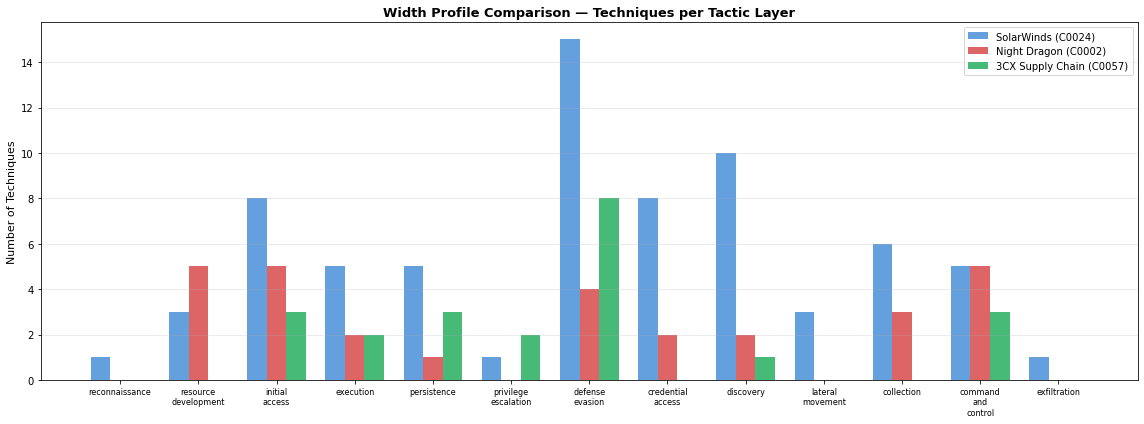


Key observations:
- These three campaigns have fundamentally different SHAPES.
- Evidence-scored edges produce sparser graphs than bipartite (see edge reduction).
- SolarWinds has rich evidence (multiple malware/tools + citations); 3CX has less.


In [14]:
# --- Comparative Analysis ---

campaign_data = [
    ('SolarWinds (C0024)', m_solar),
    ('Night Dragon (C0002)', m_night),
    ('3CX Supply Chain (C0057)', m_3cx),
]

# 1. Metrics comparison table
print("Comparative Metrics")
print("=" * 90)
header = f"{'Metric':<25s}"
for name, _ in campaign_data:
    header += f"{name:>25s}"
print(header)
print("-" * 90)

for metric_key, metric_label in [
    ('num_techniques', 'Techniques'),
    ('num_flow_edges', 'Flow edges'),
    ('num_evidence_strong', 'Evidence (strong)'),
    ('num_evidence_moderate', 'Evidence (moderate)'),
    ('num_fallback_edges', 'Fallback edges'),
    ('num_sub_edges', 'Sub-tech edges'),
    ('tactic_coverage', 'Tactic coverage'),
    ('max_width', 'Max layer width'),
    ('longest_path', 'Longest path'),
]:
    row = f"  {metric_label:<23s}"
    for _, m in campaign_data:
        row += f"{m[metric_key]:>25}"
    print(row)

# Ratio metrics (formatted as percentages)
for metric_key, metric_label in [
    ('evidence_ratio', 'Evidence ratio'),
    ('edge_reduction', 'Edge reduction'),
]:
    row = f"  {metric_label:<23s}"
    for _, m in campaign_data:
        row += f"{m[metric_key]:>24.1%}"
    print(row)

# 2. Width profile comparison (grouped bar chart)
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

all_tactics_used = set()
for _, m in campaign_data:
    for tactic, _ in m['width_profile']:
        all_tactics_used.add(tactic)

tactics_to_plot = [t for t in TACTIC_ORDER if t in all_tactics_used]
x = np.arange(len(tactics_to_plot))
bar_width = 0.25

colors = ['#4A90D9', '#D94A4A', '#27AE60']

for i, (name, m) in enumerate(campaign_data):
    width_dict = dict(m['width_profile'])
    heights = [width_dict.get(t, 0) for t in tactics_to_plot]
    ax.bar(x + i * bar_width, heights, bar_width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + bar_width)
ax.set_xticklabels([t.replace('-', '\n') for t in tactics_to_plot], fontsize=8, rotation=0)
ax.set_ylabel('Number of Techniques', fontsize=11)
ax.set_title('Width Profile Comparison — Techniques per Tactic Layer', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- These three campaigns have fundamentally different SHAPES.")
print("- Evidence-scored edges produce sparser graphs than bipartite (see edge reduction).")
print("- SolarWinds has rich evidence (multiple malware/tools + citations); 3CX has less.")


## Part 4: Batch Analysis — All Campaigns

Build attack graphs for all campaigns with >= 3 techniques to understand the structural diversity across the full MITRE ATT&CK campaign dataset.

In [15]:
# Build attack graphs for all campaigns (>= 3 techniques) with evidence scoring

MIN_TECHNIQUES = 3
all_campaign_metrics = []

for campaign in campaigns:
    ext_id = get_ext_id(campaign)
    techs = get_campaign_techniques(campaign['id'])
    if len(techs) < MIN_TECHNIQUES:
        continue
    
    sw_groups = get_campaign_software_groups(campaign['id'], [t['ext_id'] for t in techs])
    cite_clusters = get_citation_clusters(techs)
    
    G, pos = build_campaign_attack_graph(
        techs,
        cooccurrence_index=COOCCURRENCE_INDEX,
        software_groups=sw_groups,
        citation_clusters=cite_clusters,
    )
    m = compute_graph_metrics(G)
    m['campaign_id'] = ext_id
    m['campaign_name'] = campaign['name']
    m['total_techniques_raw'] = len(techs)
    all_campaign_metrics.append(m)

    # Verify DAG invariant
    assert nx.is_directed_acyclic_graph(G), f"{ext_id}: Not a DAG!"
    assert nx.has_path(G, 'START', 'END'), f"{ext_id}: No START->END path!"

print(f"Built attack graphs for {len(all_campaign_metrics)} campaigns (>= {MIN_TECHNIQUES} techniques)")
print(f"All graphs verified: DAG property ✓, START→END reachability ✓")
print(f"Skipped {len(campaigns) - len(all_campaign_metrics)} campaigns with < {MIN_TECHNIQUES} techniques")

# Sort by technique count
all_campaign_metrics.sort(key=lambda x: x['num_techniques'], reverse=True)

# Summary table with evidence metrics
print(f"\n{'Campaign':<45s} {'Techs':>5s} {'Tac':>3s} {'MaxW':>4s} {'Flow':>5s} {'Ev.S':>4s} {'Ev.M':>4s} {'Fall':>4s} {'Ev%':>5s} {'Red%':>5s}")
print("-" * 95)
for m in all_campaign_metrics:
    name = f"{m['campaign_id']} {m['campaign_name']}"
    if len(name) > 43:
        name = name[:40] + "..."
    print(f"  {name:<43s} {m['num_techniques']:>5d} {m['tactic_coverage']:>3d} {m['max_width']:>4d}"
          f" {m['num_flow_edges']:>5d} {m['num_evidence_strong']:>4d} {m['num_evidence_moderate']:>4d}"
          f" {m['num_fallback_edges']:>4d} {m['evidence_ratio']:>4.0%} {m['edge_reduction']:>4.0%}")

# Summary statistics
ev_ratios = [m['evidence_ratio'] for m in all_campaign_metrics]
reductions = [m['edge_reduction'] for m in all_campaign_metrics]
print(f"\nEvidence ratio:  min={min(ev_ratios):.0%}, max={max(ev_ratios):.0%}, mean={sum(ev_ratios)/len(ev_ratios):.0%}")
print(f"Edge reduction:  min={min(reductions):.0%}, max={max(reductions):.0%}, mean={sum(reductions)/len(reductions):.0%}")


Built attack graphs for 51 campaigns (>= 3 techniques)
All graphs verified: DAG property ✓, START→END reachability ✓
Skipped 1 campaigns with < 3 techniques

Campaign                                      Techs Tac MaxW  Flow Ev.S Ev.M Fall   Ev%  Red%
-----------------------------------------------------------------------------------------------
  C0024 SolarWinds Compromise                    71  13   15   254   52  125   75  70%  36%
  C0014 Operation Wocao                          70  13   19   275    3  162  108  60%  25%
  C0022 Operation Dream Job                      55  12   13   171   32  107   26  84%  13%
  C0058 SharePoint ToolShell Exploitation        35  14    5    75   41   28    3  96%   3%
  C0015 C0015                                    34  11    9    90   20   44   23  74%  19%
  C0012 Operation CuckooBees                     33   9   15    82    0   50   30  62%   7%
  C0029 Cutting Edge                             31  12    5    62   16   30   10  82%  16%
  C0002 

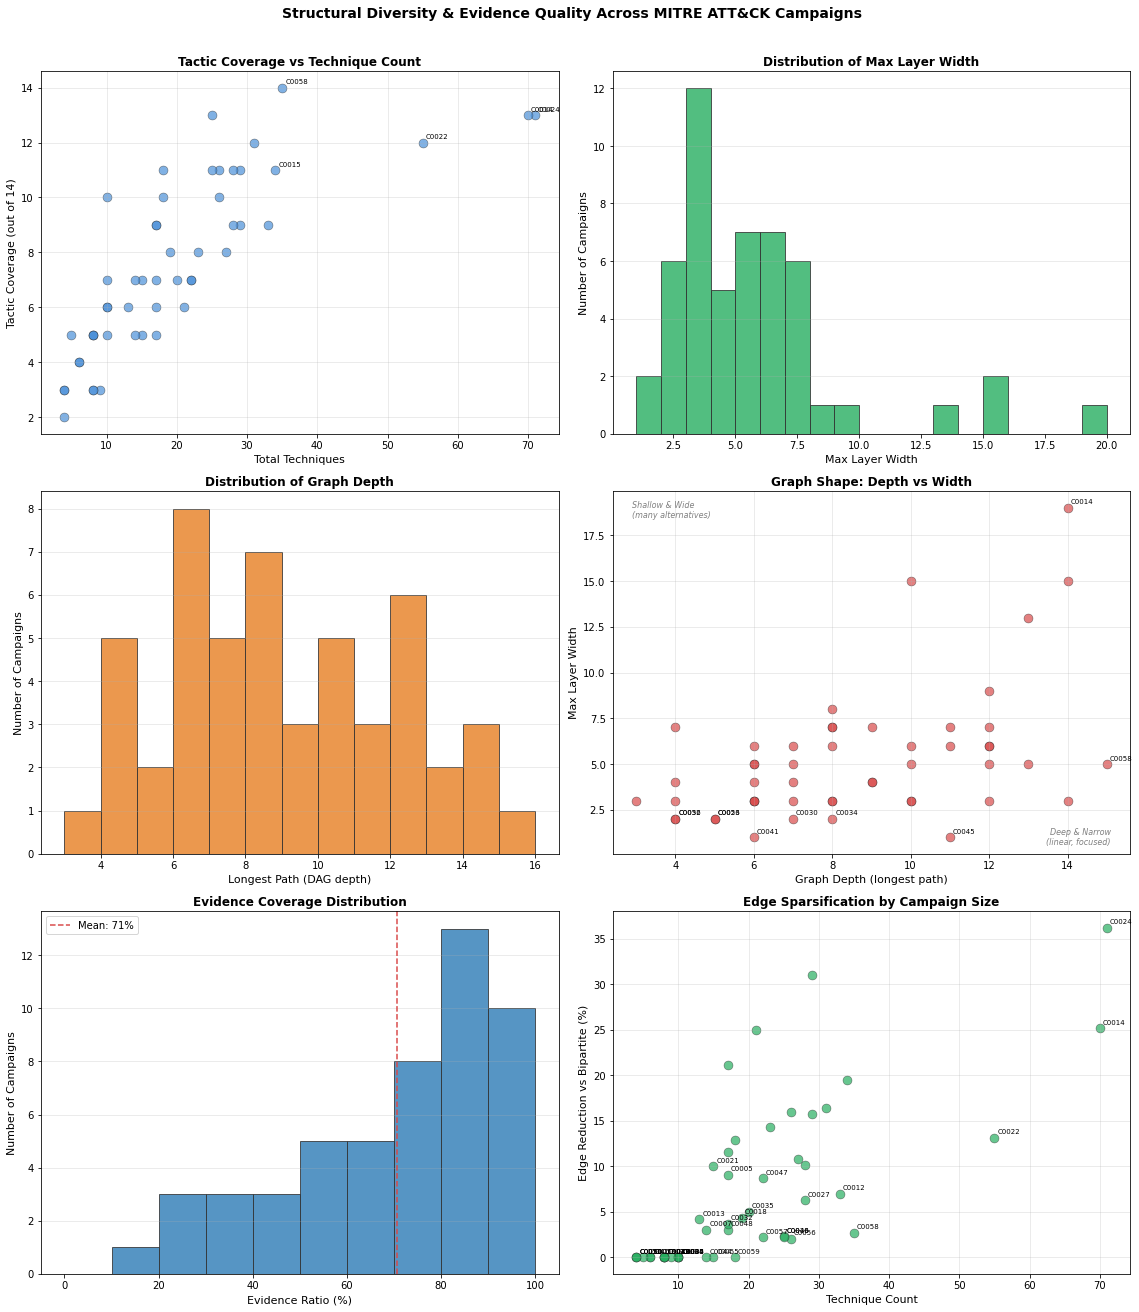

Most LINEAR campaign:       C0045 ShadowRay (max width=1)
Most BUSHY campaign:        C0014 Operation Wocao (max width=19)
Best evidence coverage:     C0018 C0018 (100%)
Lowest evidence coverage:   C0010 C0010 (12%)


In [16]:
# Structural diversity and evidence quality visualizations

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Tactic coverage vs total techniques (scatter)
ax = axes[0, 0]
techs_list = [m['num_techniques'] for m in all_campaign_metrics]
coverages = [m['tactic_coverage'] for m in all_campaign_metrics]
ax.scatter(techs_list, coverages, s=80, alpha=0.7, color='#4A90D9', edgecolors='#333', linewidths=0.5)
for m in all_campaign_metrics[:5]:
    ax.annotate(m['campaign_id'], (m['num_techniques'], m['tactic_coverage']),
                fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Total Techniques', fontsize=11)
ax.set_ylabel('Tactic Coverage (out of 14)', fontsize=11)
ax.set_title('Tactic Coverage vs Technique Count', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# 2. Max width histogram
ax = axes[0, 1]
max_widths = [m['max_width'] for m in all_campaign_metrics]
ax.hist(max_widths, bins=range(1, max(max_widths) + 2), color='#27AE60', alpha=0.8, edgecolor='#333')
ax.set_xlabel('Max Layer Width', fontsize=11)
ax.set_ylabel('Number of Campaigns', fontsize=11)
ax.set_title('Distribution of Max Layer Width', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 3. Longest path distribution
ax = axes[1, 0]
paths = [m['longest_path'] for m in all_campaign_metrics]
ax.hist(paths, bins=range(min(paths), max(paths) + 2), color='#E67E22', alpha=0.8, edgecolor='#333')
ax.set_xlabel('Longest Path (DAG depth)', fontsize=11)
ax.set_ylabel('Number of Campaigns', fontsize=11)
ax.set_title('Distribution of Graph Depth', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 4. Max width vs longest path (shape characterization)
ax = axes[1, 1]
ax.scatter(paths, max_widths, s=80, alpha=0.7, color='#D94A4A', edgecolors='#333', linewidths=0.5)
for m in all_campaign_metrics:
    if m['max_width'] == max(max_widths) or m['longest_path'] == max(paths) or m['max_width'] <= 2:
        ax.annotate(m['campaign_id'], (m['longest_path'], m['max_width']),
                    fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Graph Depth (longest path)', fontsize=11)
ax.set_ylabel('Max Layer Width', fontsize=11)
ax.set_title('Graph Shape: Depth vs Width', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[0] + 0.5, ylim[1] - 0.5, 'Shallow & Wide\n(many alternatives)',
        fontsize=8, color='gray', va='top', style='italic')
ax.text(xlim[1] - 0.5, ylim[0] + 0.5, 'Deep & Narrow\n(linear, focused)',
        fontsize=8, color='gray', ha='right', style='italic')

# 5. Evidence ratio distribution
ax = axes[2, 0]
ev_ratios = [m['evidence_ratio'] * 100 for m in all_campaign_metrics]
ax.hist(ev_ratios, bins=np.arange(0, 105, 10), color='#2C7BB6', alpha=0.8, edgecolor='#333')
ax.axvline(np.mean(ev_ratios), color='#D94A4A', linestyle='--', linewidth=1.5,
           label=f'Mean: {np.mean(ev_ratios):.0f}%')
ax.set_xlabel('Evidence Ratio (%)', fontsize=11)
ax.set_ylabel('Number of Campaigns', fontsize=11)
ax.set_title('Evidence Coverage Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 6. Edge reduction vs technique count
ax = axes[2, 1]
reductions = [m['edge_reduction'] * 100 for m in all_campaign_metrics]
techs_list2 = [m['num_techniques'] for m in all_campaign_metrics]
ax.scatter(techs_list2, reductions, s=80, alpha=0.7, color='#27AE60', edgecolors='#333', linewidths=0.5)
for m in all_campaign_metrics:
    if m['edge_reduction'] > 0.7 or m['edge_reduction'] < 0.1 or m['num_techniques'] > 50:
        ax.annotate(m['campaign_id'], (m['num_techniques'], m['edge_reduction'] * 100),
                    fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Technique Count', fontsize=11)
ax.set_ylabel('Edge Reduction vs Bipartite (%)', fontsize=11)
ax.set_title('Edge Sparsification by Campaign Size', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Structural Diversity & Evidence Quality Across MITRE ATT&CK Campaigns',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Identify extremes
most_linear = min(all_campaign_metrics, key=lambda m: m['max_width'])
most_bushy = max(all_campaign_metrics, key=lambda m: m['max_width'])
best_evidence = max(all_campaign_metrics, key=lambda m: m['evidence_ratio'])
worst_evidence = min(all_campaign_metrics, key=lambda m: m['evidence_ratio'])
print(f"Most LINEAR campaign:       {most_linear['campaign_id']} {most_linear['campaign_name']}"
      f" (max width={most_linear['max_width']})")
print(f"Most BUSHY campaign:        {most_bushy['campaign_id']} {most_bushy['campaign_name']}"
      f" (max width={most_bushy['max_width']})")
print(f"Best evidence coverage:     {best_evidence['campaign_id']} {best_evidence['campaign_name']}"
      f" ({best_evidence['evidence_ratio']:.0%})")
print(f"Lowest evidence coverage:   {worst_evidence['campaign_id']} {worst_evidence['campaign_name']}"
      f" ({worst_evidence['evidence_ratio']:.0%})")


## Part 5: How Attack Graphs Could Drive Simulator Behaviour

### Current Model Limitations
The fixed 6-phase kill chain treats every campaign identically in terms of **structure**. A SolarWinds APT with 71 techniques across 13 tactics follows the exact same SCAN_HOST → ENUM_HOST → SCAN_PORT → EXPLOIT_VULN → BRUTE_FORCE → SCAN_NEIGHBOR chain as a simple 5-technique campaign. Only durations and probabilities change.

### Graph-Driven Attack Behaviour

**1. Graph-driven phase selection**: Instead of the fixed chain, the attacker walks its campaign-specific attack graph. At each layer, it selects from available technique nodes. This means different campaigns literally follow different paths through the simulation.

**2. Width as attacker resilience**: Wider layers = more alternative paths. If an MTD disrupts one technique path, a campaign with 8 initial-access techniques has 7 fallbacks. A campaign with only 1 initial-access technique is stuck.

**3. MTD effectiveness varies by graph shape**: 
- **Network shuffle** is devastating against lateral-movement-heavy campaigns but barely affects credential-focused ones
- **Service diversity** matters most for campaigns with wide exploit layers
- The attack graph structure predicts which MTD strategies are effective against which threat actors

**4. Evidence-scored edges inform path selection**: Strong-evidence edges represent paths the attacker is more likely to follow (observed across multiple real campaigns). Fallback edges are structurally possible but less probable. This could weight path selection in simulation.

**5. Choke-point analysis**: Narrow layers in a campaign's attack graph are natural choke points — if an MTD can disrupt the single technique at a bottleneck layer, the entire campaign stalls.

### Remaining Limitations

- **Evidence signals indicate association, not causal sequence.** Co-occurring techniques may be independent capabilities, not sequential steps.
- **Tactic ordering is coarse**: Some campaigns may use techniques out of the canonical order.
- **Within-layer parallelism is assumed**: All techniques in a layer are treated as alternatives, but some may be sequential steps within the same tactic.
- **Evidence coverage varies**: Campaigns with sparse metadata get mostly fallback edges, providing less structural improvement over bipartite.


## Summary & Next Steps

### What we established
1. **MITRE ATT&CK has no pre-built attack graphs** — the data is flat campaign-to-technique relationships with no explicit sequencing
2. **The canonical tactic ordering provides a natural DAG layering** — 14 tactics in matrix order
3. **Evidence-scored edges replace naive bipartite connections** — using cross-campaign co-occurrence (PMI), shared malware/tool intermediaries, and citation co-occurrence
4. **Campaign attack graphs are structurally diverse** — different tactic coverage, width profiles, depths, and evidence quality
5. **The evidence-scoring approach is transparent** — every edge carries its classification and provenance, limitations are documented

### Evidence scoring results
- Cross-campaign co-occurrence is the strongest signal (54% mean coverage of adjacent-layer edges)
- Malware/tool intermediaries provide secondary grouping (22% mean technique coverage)
- Citation clusters discriminate for ~16/51 campaigns with multiple sources
- Edge reduction vs bipartite is meaningful for campaigns with evidence support

### Next steps
1. **Define a `CampaignAttackGraph` class** wrapping `nx.DiGraph` with the construction logic developed here
2. **Technique-to-action mapping**: Map ATT&CK techniques to simulator actions
3. **Modify `AttackOperation.proceed_attack()`** to walk the campaign graph instead of the fixed chain
4. **Weight path selection by edge evidence**: Strong-evidence edges get higher traversal probability
5. **Evaluate**: Run simulations with graph-driven attackers vs current linear attackers to quantify the difference in MTD effectiveness

### Data source considerations
- The current approach uses only the local `enterprise-attack.json` STIX bundle
- Future enrichment: MITRE CTID [Attack Flow](https://center-for-threat-informed-defense.github.io/attack-flow/) project provides explicit attack flow sequences that could replace evidence-inferred edges with ground-truth dependency data
- If explicit sequence/dependency fields are added to ATT&CK STIX in future versions, the evidence inference layer can be swapped for direct ingestion while keeping the same downstream graph API


## Part 6: From Campaign Ontology to Simulation Agent — The Fundamental Gap

### The Three Layers

**Layer 1: What ATT&CK gives you (ontology)**
- "APT29 used T1566 (Phishing) and T1059 (Command Scripting)"
- No ordering, no preconditions, no resource dependencies
- A **label set**, not a workflow

**Layer 2: What an attack graph needs (causal structure)**
- "Phishing yields initial foothold → foothold enables command execution → command execution on host X yields credential Y → credential Y enables lateral movement to host Z"
- Preconditions, postconditions, concrete resources (hosts, credentials, files)
- This is what MITRE CTID's [Attack Flow](https://center-for-threat-informed-defense.github.io/attack-flow/) project and MulVAL-style graphs provide — but they are **manually authored per scenario**

**Layer 3: What a simulation agent needs (temporal decision-making)**
- "Given my current state (foothold on host A, credential X), which action do I attempt next? How long does it take? What's the probability of success? What does the defender's MTD do to my options?"
- This is a **policy over a state space**, not a static graph

### The Gap

The gap between Layer 2 and Layer 3 is where the real problem lives:

| Aspect | Attack Graph (Layer 2) | Simulation Agent (Layer 3) |
|--------|----------------------|---------------------------|
| Time | Absent | Central — actions have duration, MTD has reconfiguration intervals |
| State | Implicit (pre/postconditions) | Explicit (which hosts compromised, which credentials held) |
| Choice | All paths shown | Agent picks one path based on policy |
| Defender | Not modeled | Active — MTD changes the graph mid-execution |
| Failure | Not modeled | Actions can fail, get detected, cost time |

### Possible Approaches to Bridge the Gap

**Approach 1: Attack graph as MDP state-transition map**
- Each node = attacker state (set of compromised resources)
- Each edge = an action (technique) with preconditions, success probability, time cost
- MTD modifies transition probabilities or removes edges dynamically
- Agent uses a policy (greedy, RL, or heuristic) to traverse
- **Most principled** but requires manually defining the state space and transitions for each scenario

**Approach 2: Attack graph as a script with stochastic execution**
- Linear or branching sequence of steps (manually authored)
- Agent follows the script but each step has P(success), P(detection), time_cost
- MTD affects these probabilities
- Simpler but less realistic — attacker does not adapt

**Approach 3: Capability-based agent (no explicit graph)**
- Agent has a set of techniques it "knows" (from campaign profile)
- At each timestep, it evaluates which techniques are applicable given current state
- Picks one based on some strategy (random, prioritised, RL)
- The "attack graph" emerges from execution rather than being prescribed
- **This is closest to what mtdnetwork's existing attacker likely does**

### Assessment for MTDSim

- **Approach 3** is pragmatic — the existing attacker agent model can be enriched by campaign profiles that constrain *which* techniques the agent can use and *how skilled* it is at each one. The ATT&CK campaign data is most useful here as a **capability profile**, not an attack graph.
- **Approach 1** is more rigorous but requires defining concrete scenarios (e.g., "3-subnet network with AD, web server, and database") with hand-crafted precondition/postcondition mappings for each relevant technique.

### Implication

The campaign attack graphs built in this notebook are valuable as **analysis** — understanding technique diversity, co-occurrence patterns, and campaign complexity. But forcing ATT&CK campaign data into a simulation-ready attack graph is fighting the data's nature. The path forward is either:
1. Use campaign data as **capability profiles** feeding a capability-based agent (Approach 3)
2. Hand-author causal attack flows for specific scenarios using MITRE Attack Flow format, then map those to simulation actions (Approach 1)
3. A hybrid: campaign profiles constrain the agent's technique repertoire, while hand-authored scenario graphs define the causal structure for key attack patterns
